<a href="https://colab.research.google.com/github/dianasoboleva1538-sketch/algoritm_tsib-23_2/blob/main/_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Лабораторная работа 2
# Курс: ЦИБ - 251
# ФИО: Соболева Диана Юрьевна
## Описание варианта
### Граф
#- Вершины: 7 верш: (1,2), (1,3), (2,4), (3,5),(5,6), (6,7)
#- Рёбра: (1,2), (1,3), (2,4), (3,5), (5,6), (6,7)
### Дерево (для построения BST)
#Исходный список элементов:  [32, 24, 38, 22, 26, 34, 41]
#Операции:
#- Найти элемент: 26
#- Удалить элемент: 24
### Куча (для Heap Sort)
#Исходный массив:  [32, 24, 38, 22, 26, 34, 41]
## Описание реализации
### Структуры данных
#- Граф: представлен списком смежности (`defaultdict(list)`), а также матрицей смежности (`list[list[int]]`).
#- Бинарное дерево поиска (BST): реализовано в виде класса `Node` с атрибутами `value, left, right`.
#- Куча: реализована на месте (in-place) в массиве для алгоритма Heap Sort.


def heapify(arr, n, i): (сделать так, чтобы код нарисовал граф функции)
    largest = i
    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left] > arr[largest]:
        largest = left
    if right < n and arr[right] > arr[largest]:
        largest = right

    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)

def heap_sort(arr):
    n = len(arr)

    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i)

    for i in range(n - 1, 0, -1):
        arr[i], arr[0] = arr[0], arr[i]
        heapify(arr, i, 0)


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


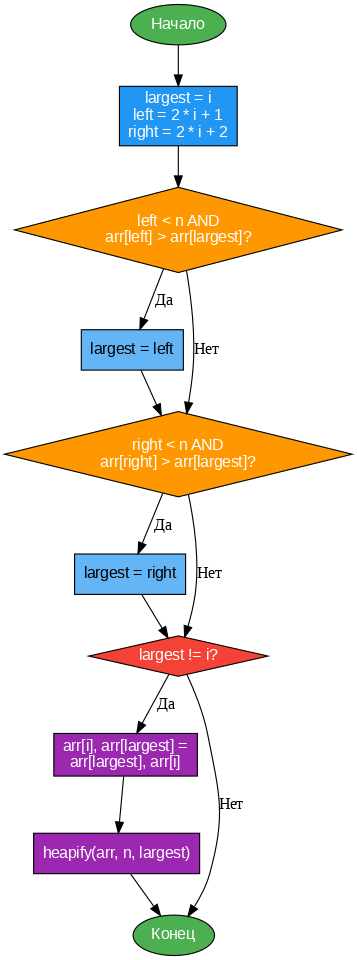

In [2]:
# 1. Установка Graphviz (нужно сделать один раз)
!apt-get install -y graphviz
!pip install graphviz

import graphviz

# 2. Создание объекта графа
# rankdir='TB' означает Top-to-Bottom (сверху вниз)
dot = graphviz.Digraph('heapify_flowchart', format='png')
dot.attr(rankdir='TB', size='8,10')
dot.attr('node', shape='box', style='filled', fontname='Arial')

# --- Определение стилей для разных типов блоков ---
# start_end: Овалы начала/конца (зеленые)
# process: Прямоугольники действий (синие)
# decision: Ромбы условий (оранжевые/красные)

# 3. Добавление узлов (Nodes)

# Начало
dot.node('start', 'Начало', shape='ellipse', fillcolor='#4CAF50', fontcolor='white')

# Инициализация переменных
dot.node('init', 'largest = i\nleft = 2 * i + 1\nright = 2 * i + 2',
         shape='rectangle', fillcolor='#2196F3', fontcolor='white')

# Проверка левого потомка
dot.node('check_left', 'left < n AND\narr[left] > arr[largest]?',
         shape='diamond', fillcolor='#FF9800', fontcolor='white')

# Действие: largest = left
dot.node('set_left', 'largest = left',
         shape='rectangle', fillcolor='#64B5F6', fontcolor='black')

# Проверка правого потомка
dot.node('check_right', 'right < n AND\narr[right] > arr[largest]?',
         shape='diamond', fillcolor='#FF9800', fontcolor='white')

# Действие: largest = right
dot.node('set_right', 'largest = right',
         shape='rectangle', fillcolor='#64B5F6', fontcolor='black')

# Проверка на обмен (largest != i)
dot.node('check_swap', 'largest != i?',
         shape='diamond', fillcolor='#F44336', fontcolor='white')

# Действие: Обмен элементов
dot.node('do_swap', 'arr[i], arr[largest] =\narr[largest], arr[i]',
         shape='rectangle', fillcolor='#9C27B0', fontcolor='white')

# Рекурсивный вызов
dot.node('recurse', 'heapify(arr, n, largest)',
         shape='rectangle', fillcolor='#9C27B0', fontcolor='white')

# Конец
dot.node('end', 'Конец', shape='ellipse', fillcolor='#4CAF50', fontcolor='white')

# 4. Добавление связей (Edges)

# Начало -> Инициализация
dot.edge('start', 'init')

# Инициализация -> Проверка левого
dot.edge('init', 'check_left')

# Логика левого потомка
dot.edge('check_left', 'set_left', label='Да')
dot.edge('check_left', 'check_right', label='Нет')

# После установки left идем проверять right
dot.edge('set_left', 'check_right')

# Логика правого потомка
dot.edge('check_right', 'set_right', label='Да')
dot.edge('check_right', 'check_swap', label='Нет')

# После установки right идем проверять swap
dot.edge('set_right', 'check_swap')

# Логика обмена
dot.edge('check_swap', 'do_swap', label='Да')
dot.edge('check_swap', 'end', label='Нет') # Если менять не надо — конец

# Обмен -> Рекурсия -> Конец (или возврат)
# В блок-схемах рекурсию часто рисуют как возврат к началу или отдельный блок
dot.edge('do_swap', 'recurse')
dot.edge('recurse', 'end')

# 5. Рендеринг и отображение
# render() создаст файл 'heapify_flowchart.png'
dot.render('heapify_flowchart', view=False)

# Отображение картинки прямо в Colab
from IPython.display import Image
Image('heapify_flowchart.png')

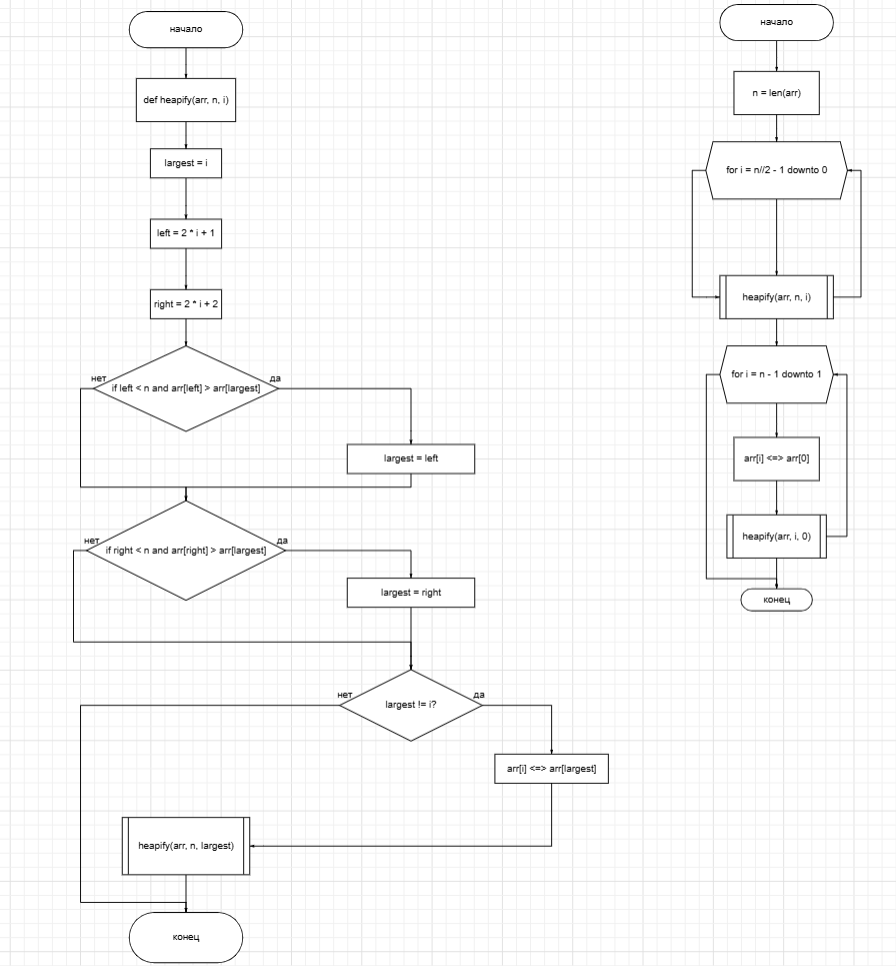

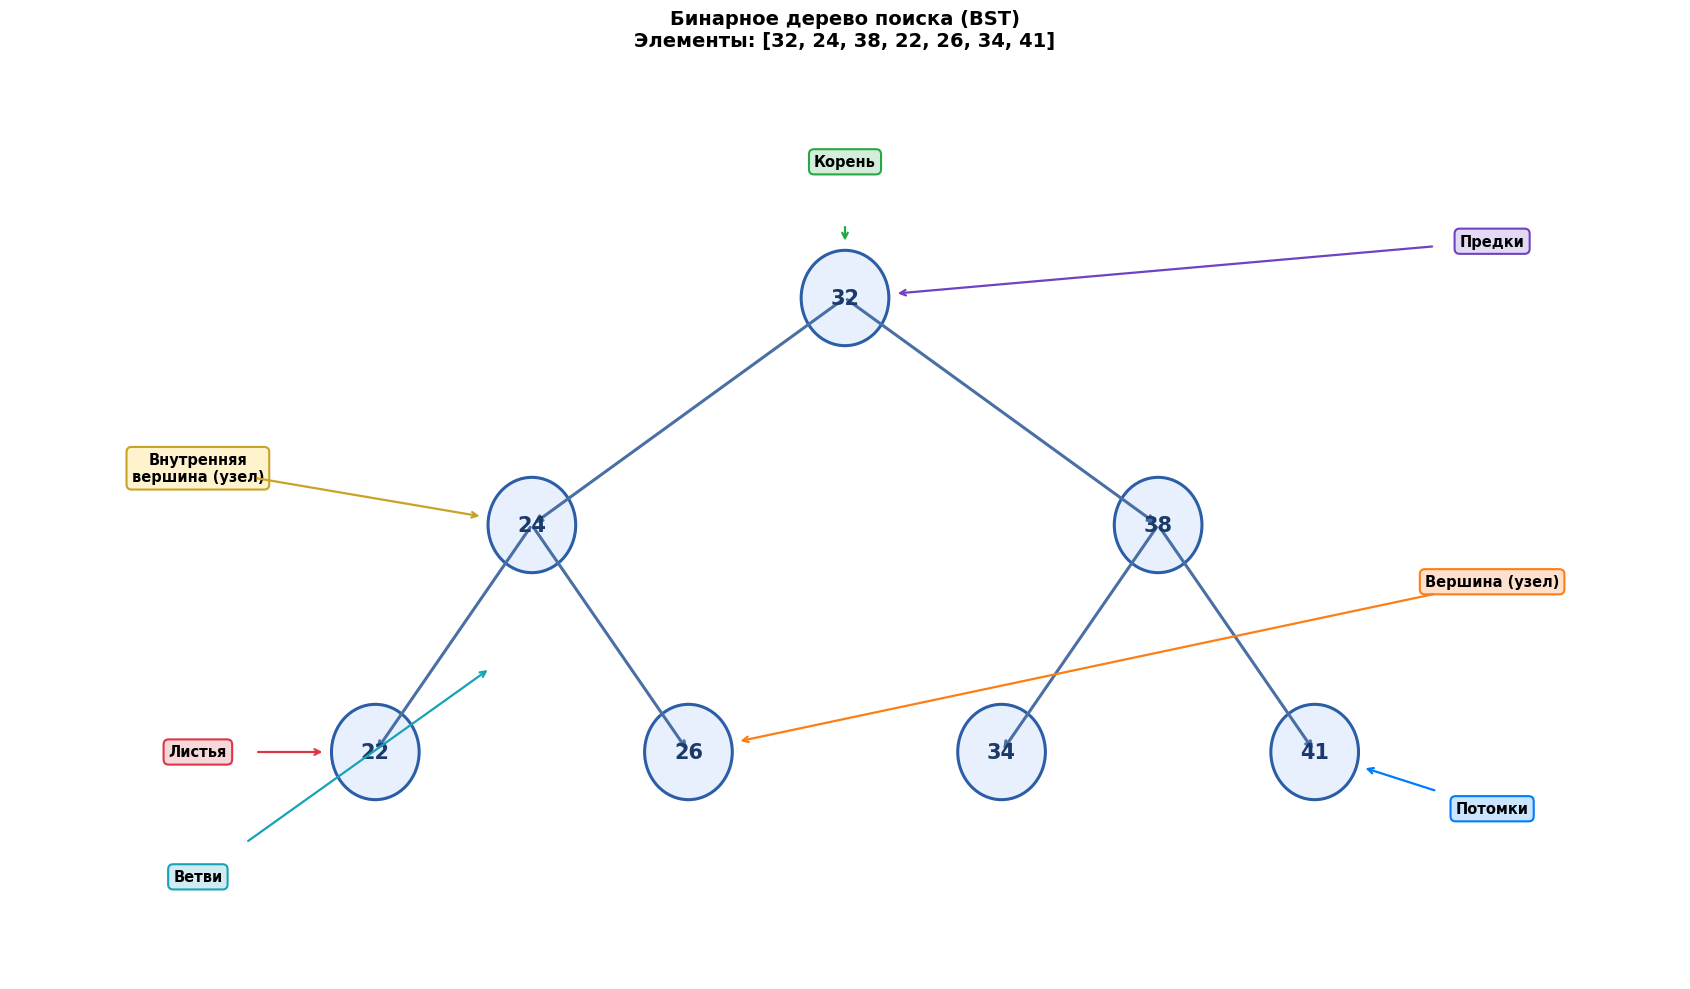